# Slice-by-slice buffer subtraction and the low-q mask: run 409

**Question.** The static mask (`mask_2026-09-08_AGIPD_SAXS.npy`) removes every azimuthal "pizza slice" near the beam except
one wedge (χ ≈ 0–60°), because those slices carry stray light. If the buffer is subtracted slice by slice, do some of the
masked slices become usable, so that the mask can be opened and the low-q region gets more pixels?

**Test case.** Run 409, the first run of a fresh ferritin + PEG 1K droplet (runs 409–419, 11 May). The buffer is the
PEG 6K buffer droplet r464 → r466 (12 May) at the same normalised time t/t\*, as in `damnit_saxs.ipynb`. As a control,
the same buffer is subtracted from r443, a fresh ferritin + PEG 6K droplet recorded under the buffer's own (12 May)
stray-light pattern.

### Findings

1. **What the near-beam slices are.** The 2026-09-08 mask is the 2026-05-19 base mask plus 61 491 pixels of slices around
   the beam (q 0.125–0.41 nm⁻¹); it also uses again 1 688 pixels next to the wedge that the base mask excluded. Below q = 0.125 nm⁻¹ the
   base mask and the detector layout leave only the wedge anyway, so **no slice can add pixels below 0.125 nm⁻¹**. Above,
   removing the near-beam slices would give 1.6× (0.125–0.15), 2.8× (0.15–0.2) and 2.5× (0.2–0.3) more pixels.
2. **Below q ≈ 0.2 nm⁻¹ the masked slices lie almost entirely in the stray-light lobe** (χ ≈ −90° to −20°), and for r409
   the lobe does not subtract: it comes out at 0.25–0.9 of the wedge's value at q = 0.13–0.2 nm⁻¹ (over-subtracted). Per
   unit flux the 12 May buffer carries a 3–16× stronger lobe than r409, so no single buffer scale can fix it.
3. **In the same-period control the lobe goes the other way and can be fixed.** With the standard scaling (both per
   flux × path) r443's lobe is under-subtracted (1.3–2× the wedge); subtracting the buffer per unit flux instead, the
   scaling stray light needs, makes most lobe cells agree with the wedge down to q ≈ 0.2 nm⁻¹ (27 000 of 31 000 masked
   pixels at 0.2–0.3 nm⁻¹, 2 300 of 6 200 at 0.15–0.2 nm⁻¹), but almost none below 0.15 nm⁻¹ (120 of 740).
4. **Above q ≈ 0.2 nm⁻¹, slices outside the lobe core agree after the standard subtraction** in all three r409 blocks.
   Opening them adds 30 500 pixels: 1.7× at 0.2–0.3 nm⁻¹, 1.2× at 0.3–0.42 nm⁻¹ and 1.15× at 0.15–0.2 nm⁻¹; the subtracted
   I(q) changes by less than 1 %. This is a statistics gain where statistics are already good, not new low-q information.
5. **The wedge itself is consistent for r409 down to q ≈ 0.13 nm⁻¹ in all three blocks**, although the rule used in
   `damnit_saxs.ipynb` (q_min = 0.156 nm⁻¹ per mm of horizontal semi-axis) predicts 0.19 nm⁻¹ for the start of r409. That
   droplet starts very flat (semi-axes 1.23 mm horizontal, 0.46 mm vertical), and the rule was measured on r443–452.
6. **The 11 May stray light resembles the beam-only pattern of the r318 mesh scan** (11 May, attenuator 0.1): the same
   lobe directions, with a lobe excess per logged flux ~3× r409's. r318 cannot serve as a reference without a fitted scale.

**In short:** for r409, slice-wise subtraction against the 12 May buffer does not recover anything below q ≈ 0.2 nm⁻¹,
because the buffer's stray light comes from the other stray-light period. For 12 May samples, a per-flux subtraction of
the lobe slices would recover them above ≈ 0.2 nm⁻¹.

### How to run

Kernel `mid-10400`. Nothing is read from the corrected detector files: the per-pixel photon sums are the integration
pass's window sums (`analysis.saxs.pixel_sums`, 10 trains per window, under `usr/cached_files/agipd_pixel_sums`), and the
per-train scale factors come from `analysis.cache` (`scratch/saxs_cache`). The one exception is the r318 beam-only
group of section 6, trains scattered over the mesh scan, whose sums `analysis.cache.detector_sums` read once and cached.
A full run takes about a minute.

### Glossary

* **q, χ:** scattering vector (nm⁻¹) and pyFAI azimuth (degrees) of each pixel, exactly as the `agipd_saxs` pass computed
  them (`geom_latest.geom`, 7.531 m, 9.04 keV, beam centre (607.46, 672.08) px).
* **Slice:** a 15°-wide azimuthal sector; a **cell** is one slice × one q bin.
* **Block:** five 10-train windows of the integration pass whose trains are all complete (50 trains, 155 frames each);
  per-pixel photon sums from `analysis.saxs.pixel_sums`, raw and unnormalised.
* **F, tT, φ:** flux (XGM × attenuator transmission), droplet path × transmission, ferritin volume fraction
  (`analysis.cache.saxs_run`, block means).
* **Standard subtraction:** D = S/(F·tT)_sample − (1 − φ)·B/(F·tT)_buffer, as in `damnit_saxs.ipynb`.
* **Per-flux subtraction:** D = (S/F_sample − B/F_buffer)/tT_sample + (tT_buffer/tT_sample − (1 − φ))·⟨B⟩/(F·tT)_buffer, where
  ⟨B⟩ is the buffer's current-mask average. Stray light that scales with flux alone cancels in the first term.
* **t/t\*:** time since the droplet was fresh divided by t\*, the end of its D² evaporation law.

In [1]:
%matplotlib inline
import json
import logging
import os
from pathlib import Path
import warnings

logging.getLogger("silx").setLevel(logging.ERROR)  # a harmless "no pyOpenCL" notice from pyFAI's backend
os.environ.setdefault("EXTRA_NUM_THREADS", "1")

import damnit
import extra_data as ed
import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from extra_geom import AGIPD_1MGeometry
from matplotlib.colors import LogNorm
from pyFAI.integrator.azimuthal import AzimuthalIntegrator

from analysis import cache
from analysis.saxs import pixel_sums
from analysis.saxs.config import DEFAULT_PIXEL_SUMS_ROOT, SHAPE, AgipdSaxsConfig

np.seterr(divide="ignore", invalid="ignore")  # NaN marks cells without data
warnings.filterwarnings("ignore", message="Mean of empty slice")
plt.rcParams.update({"figure.dpi": 90, "font.size": 10})
pd.set_option("display.precision", 3)
db = damnit.Damnit(10400)

## 0. Geometry and what the mask is made of

Pixel q and χ as the `agipd_saxs` pass computed them. Three masks are compared:

* **current:** `mask_2026-09-08_AGIPD_SAXS.npy`, the one every I(q) in this proposal uses;
* **base:** `mask_2026-05-19.npy`, from which the current one was built;
* **current without the near-beam slices:** pixels masked by both (the base mask, keeping the low-q corner the current
  mask opened). The slice study below uses this one.

In [2]:
PASS_FILE = "/gpfs/exfel/exp/MID/202601/p010400/scratch/agipd_saxs/r{run:04d}/agipd_saxs.h5"
MASK_DIR = "/gpfs/exfel/exp/MID/202601/p010400/usr/masks"
MSHAPE = (16, 512, 128)


def pass_geometry(run):
    "Pixel q (nm^-1), azimuth chi (deg) and the static mask, as the agipd_saxs pass of `run` used them."
    with h5py.File(PASS_FILE.format(run=run)) as h:
        cfg = AgipdSaxsConfig(**json.loads(h["provenance"].attrs["config"]))
        bad = np.unpackbits(h["masks/static_bad_packed"][:])[: SHAPE[0] * SHAPE[1]]
    geom = AGIPD_1MGeometry.from_crystfel_geom(cfg.geometry_file)
    detector = geom.to_pyfai_detector()
    detector.set_pixel_corners(geom.to_distortion_array())  # the frame the beam centre is defined in
    ai = AzimuthalIntegrator(detector=detector, wavelength=cfg.wavelength_m)
    ai.setFit2D(cfg.sdd_m * 1e3, *cfg.beam_center)
    q = ai.center_array(SHAPE, unit="q_nm^-1").reshape(MSHAPE)
    chi = np.rad2deg(ai.center_array(SHAPE, unit="chi_rad")).reshape(MSHAPE)
    return q, chi, bad.astype(bool).reshape(MSHAPE), geom, cfg


Q, CHI, STATIC_BAD, GEOM, CFG = pass_geometry(409)
CURRENT = np.load(f"{MASK_DIR}/mask_2026-09-08_AGIPD_SAXS.npy").astype(bool)  # True = excluded
BASE = np.load(f"{MASK_DIR}/mask_2026-05-19.npy").astype(bool)
assert (CURRENT == STATIC_BAD).all(), "the pass did not use the current mask file"
NEAR_BEAM = CURRENT & ~BASE  # the slices added around the beam
OPENED = BASE & ~CURRENT  # base pixels the current mask uses again
OPEN_MASK = CURRENT & BASE  # current mask without the near-beam slices
print(f"near-beam slices: {NEAR_BEAM.sum()} px at q {Q[NEAR_BEAM].min():.3f}-{Q[NEAR_BEAM].max():.3f} nm^-1; "
      f"opened base pixels: {OPENED.sum()} px at q {Q[OPENED].min():.3f}-{Q[OPENED].max():.3f} nm^-1")

rows = []
for lo, hi in [(0.08, 0.10), (0.10, 0.125), (0.125, 0.15), (0.15, 0.20), (0.20, 0.30), (0.30, 0.42)]:
    ring = (Q >= lo) & (Q < hi)
    rows.append({"q (nm⁻¹)": f"{lo:.3f}–{hi:.3f}", "detector pixels": int(ring.sum()),
                 "used by the current mask": int((ring & ~CURRENT).sum()),
                 "without the near-beam slices": int((ring & ~OPEN_MASK).sum())})
tab = pd.DataFrame(rows).set_index("q (nm⁻¹)")
tab["gain"] = tab["without the near-beam slices"] / tab["used by the current mask"]
tab

near-beam slices: 61491 px at q 0.125-0.408 nm^-1; opened base pixels: 1688 px at q 0.082-0.360 nm^-1


,detector pixels,used by the current mask,without the near-beam slices,gain
q (nm⁻¹),,,,
0.080–0.100,449,293,293,1.000
0.100–0.125,3365,935,935,1.000
0.125–0.150,6498,1383,2146,1.552
0.150–0.200,21168,3779,10629,2.813
0.200–0.300,61851,17592,44733,2.543
0.300–0.420,124758,86999,113736,1.307


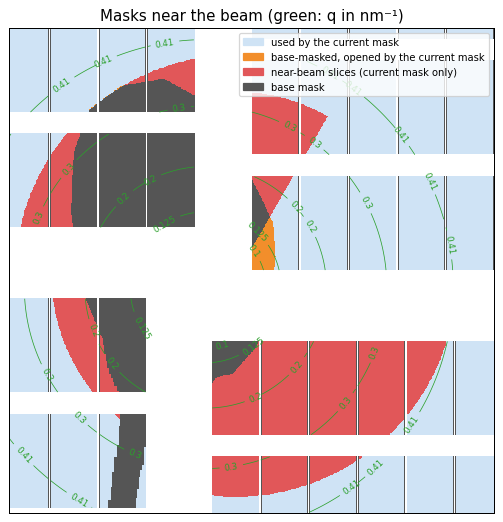

In [3]:
QA, _ = GEOM.position_modules(Q)
BEAM = np.unravel_index(np.nanargmin(QA), QA.shape)  # assembled pixel nearest q = 0
category = np.select([OPENED, NEAR_BEAM, BASE], [1.0, 2.0, 3.0], 0.0)
img, _ = GEOM.position_modules(category)
half = 330
w = (slice(BEAM[0] - half, BEAM[0] + half), slice(BEAM[1] - half, BEAM[1] + half))
colors = ["#cfe3f5", "#f28e2b", "#e15759", "#555555"]
cmap = mpl.colors.ListedColormap(colors)
cmap.set_bad("white")
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(img[w], cmap=cmap, norm=mpl.colors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], 4), origin="lower",
          interpolation="nearest")
cs = ax.contour(QA[w], levels=[0.1, 0.125, 0.2, 0.3, 0.41], colors="tab:green", linewidths=0.6)
ax.clabel(cs, fmt="%.3g", fontsize=7)
ax.legend(handles=[mpl.patches.Patch(color=c, label=l) for c, l in zip(colors, [
    "used by the current mask", "base-masked, opened by the current mask", "near-beam slices (current mask only)",
    "base mask"])], fontsize=8, loc="upper right")
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Masks near the beam (green: q in nm⁻¹)")
plt.show()

## 1. Data blocks

Three blocks of r409 (start, middle and end of the run) and, for each, the 50 buffer trains nearest in t/t\* (the buffer
droplet's t\* is the end of its clean data, as in `damnit_saxs.ipynb`). The control is the start of r443 with the buffer
block matched to it. All four sample blocks are at attenuator 1.0, like the buffer.

In [4]:
N_WINDOWS = 5  # 10-train windows of the integration pass per block (50 trains)
SAMPLE_RUNS, BUFFER_RUNS, CONTROL_RUNS = list(range(409, 420)), [464, 465, 466], [443, 444, 445, 446, 448, 449, 450, 451, 452]


def usable_tids(rd, n_pulses=155):
    "Complete trains with a scale factor, picked by train id."
    ok = (rd.n_pulses_with_frames == n_pulses) & np.isfinite(rd.scale)
    return rd.trainId.values[ok.values]


def full_windows(run, good_tids):
    "Windows of the pass's per-pixel sums whose trains were all summed and are all in `good_tids`, in time order."
    table = pixel_sums.window_table(Path(DEFAULT_PIXEL_SUMS_ROOT) / f"r{run:04d}" / pixel_sums.FILE_NAME)
    length = int(table.attrs["window_trains"])  # a window is a range of `length` train ids
    good = {int(t) for t in good_tids}
    return [int(w) for w, start, n, written in zip(table.window.values, table.start_trainId.values,
                                                  table.n_trains.values, table.written.values)
            if written and n == length and all(int(start) + k in good for k in range(length))]


def make_block(run, windows, rd, label):
    "Per-pixel photon sums over whole windows of the pass (raw) and the block's mean flux and droplet quantities."
    return block_from_sums(run, pixel_sums.detector_sums(run, windows=windows), rd, label)


def block_from_sums(run, sums, rd, label):
    "The block from per-pixel sums (the pass's windows or analysis.cache.detector_sums) and the run's per-train data."
    train_ids = sums.train_id.values
    s = rd.sel(trainId=train_ids)
    return {
        "name": f"r{run} {label}", "run": run, "trains": train_ids,
        "counts": sums.counts.values.astype(float), "valid": sums.valid_frames.values.astype(float),
        "flux": float(s.flux.mean()), "path": float(s.path_mm.mean()), "T": float(s.droplet_transmission.mean()),
        "a_x": float(s.chord_mm.mean()) / 2, "phi": float(s.phi_ferritin.mean()), "vv0": float(s.v_over_v0.mean()),
    }


def tau_of(tl, tids):
    return float((tl.elapsed_s.sel(trainId=np.asarray(tids, np.uint64)) / tl.attrs["t_star_s"]).mean())


def sample_block(run, where, tl, **kw):
    rd = cache.saxs_run(run, db, **kw)
    windows = full_windows(run, usable_tids(rd))
    start = {"start": 0, "middle": (len(windows) - N_WINDOWS) // 2, "end": len(windows) - N_WINDOWS}[where]
    b = make_block(run, windows[start : start + N_WINDOWS], rd, where)
    b["tau"] = tau_of(tl, b["trains"])
    return b


def buffer_block(tau, tl_b):
    "N_WINDOWS usable buffer windows (one run) centred on the buffer train nearest in t/t*."
    tau_b = (tl_b.elapsed_s / tl_b.attrs["t_star_s"]).where(tl_b.used_in_fit).dropna("trainId")
    tid0 = int(tau_b.trainId.values[int(np.argmin(abs(tau_b.values - min(tau, float(tau_b.max())))))])
    run = int(tl_b.run.sel(trainId=tid0))
    rd = cache.saxs_run(run, db, v0_run=BUFFER_RUNS[0], ferritin_mg_per_ml_initial=0)
    windows = full_windows(run, np.intersect1d(usable_tids(rd), tau_b.trainId.values))
    starts = pixel_sums.window_table(Path(DEFAULT_PIXEL_SUMS_ROOT) / f"r{run:04d}" / pixel_sums.FILE_NAME).start_trainId
    j = int(np.argmin([abs(int(starts[w]) - tid0) for w in windows]))  # the window nearest tid0
    j0 = int(np.clip(j - N_WINDOWS // 2, 0, len(windows) - N_WINDOWS))
    b = make_block(run, windows[j0 : j0 + N_WINDOWS], rd, f"tau{tau:.3f}")
    b["tau"] = tau_of(tl_b, b["trains"])
    return b


tl_s = cache.droplet_timeline(SAMPLE_RUNS, db)
tl_c = cache.droplet_timeline(CONTROL_RUNS, db)
tl_b = cache.droplet_timeline(BUFFER_RUNS, db, stop_at_min_volume=True, t_star="end")
pairs = {}
for where in ("start", "middle", "end"):
    s = sample_block(409, where, tl_s, v0_run=409)
    pairs[f"r409 {where}"] = (s, buffer_block(s["tau"], tl_b))
s = sample_block(443, "start", tl_c, v0_run=443)
pairs["control r443 start"] = (s, buffer_block(s["tau"], tl_b))

pd.DataFrame([{"pair": k, "block": b["name"], "t/t*": b["tau"], "V/V0": b["vv0"], "a_x (mm)": b["a_x"],
               "T": b["T"], "tT (mm)": b["path"], "flux": b["flux"], "φ": b["phi"]}
              for k, pair in pairs.items() for b in pair]).set_index(["pair", "block"])

t/t*   V/V0  a_x (mm)      T  tT (mm)  \
pair               block                                                   
r409 start         r409 start     0.002  0.997     1.227  0.101    0.247   
                   r464 tau0.002  0.003  0.994     0.734  0.328    0.482   
r409 middle        r409 middle    0.132  0.718     0.873  0.168    0.293   
                   r464 tau0.132  0.133  0.805     0.661  0.362    0.478   
r409 end           r409 end       0.261  0.588     0.819  0.168    0.275   
                   r464 tau0.261  0.261  0.648     0.602  0.391    0.470   
control r443 start r443 start     0.002  0.991     0.960  0.165    0.317   
                   r464 tau0.002  0.003  0.994     0.734  0.328    0.482   

                                     flux      φ  
pair               block                          
r409 start         r409 start     325.812  0.031  
                   r464 tau0.002  359.541  0.000  
r409 middle        r409 middle    323.209  0.043  
                   r464 tau0.132  364.141  0.000  
r409 end           r409 end       335.973  0.052  
                   r464 tau0.261  363.262  0.000  
control r443 start r443 start     327.928  0.031  
                   r464 tau0.002  359.541  0.000

## 2. The slices before and after subtraction

Each panel shows, per slice and q bin, the intensity divided by the current mask's azimuthal average at that q (1 = same
as what the analysis uses now). White = no pixels in that cell, even without the near-beam slices. Cells inside the black
outlines are the ones the current mask removes (the near-beam slices); all other coloured cells are used now.

* **Sample and buffer:** the lobe at χ ≈ −90° to −20° (q 0.13–0.35 nm⁻¹) is much stronger in the 12 May buffer than in r409.
* **Subtracted, r409:** the lobe slices drop well below 1 (over-subtracted).
* **Subtracted, control r443:** the same slices stay above 1 (under-subtracted): within one stray-light period the
  standard scaling removes too little stray light, because stray light scales with the flux alone while the subtraction
  scales the buffer by (1 − φ)·tT_sample/tT_buffer ≈ 0.6.

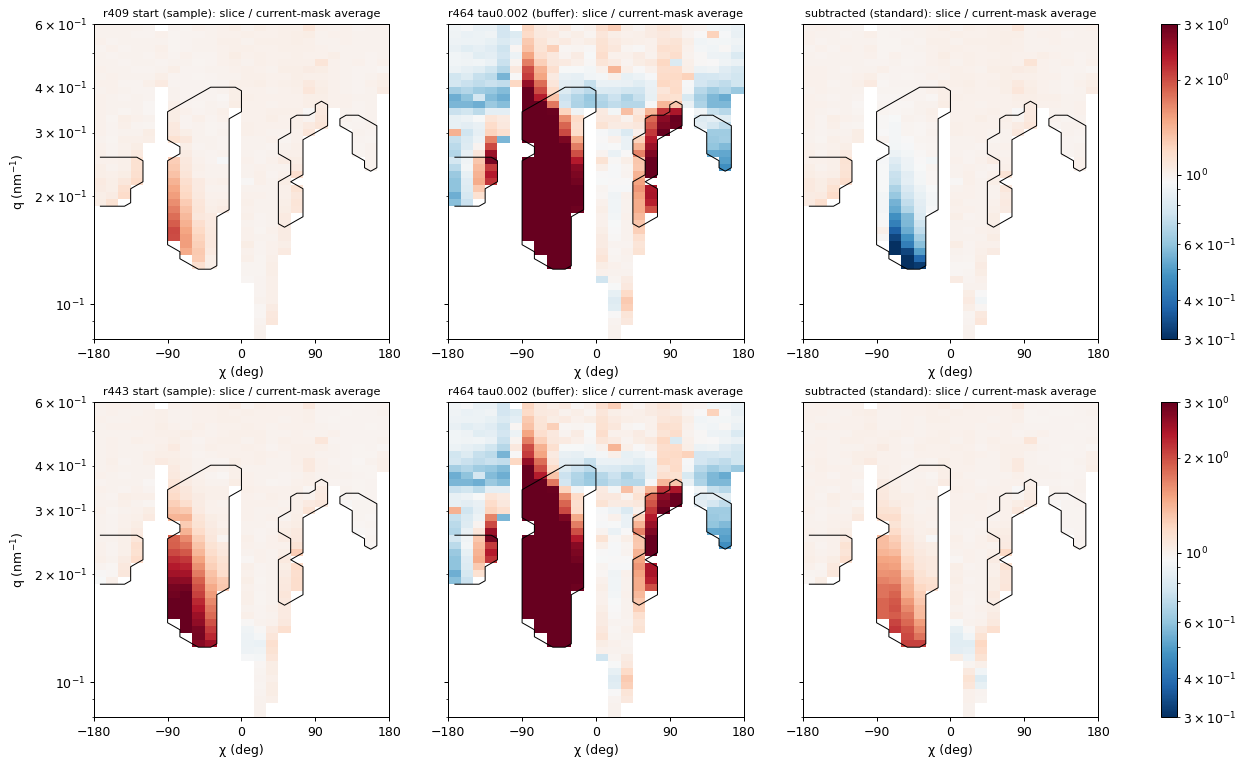

In [5]:
QE = np.geomspace(0.08, 0.6, 46)  # q bin edges (nm^-1)
QC = np.sqrt(QE[1:] * QE[:-1])
CE = np.arange(-180, 181, 15)  # slice edges (deg)
CC = 0.5 * (CE[1:] + CE[:-1])
QBIN = np.digitize(Q, QE) - 1
CBIN = np.clip(np.digitize(CHI, CE) - 1, 0, CC.size - 1)


def cells(b, used):
    "Photons per pixel per frame in each (q bin, slice) cell, pooled over the pixels in `used`; and pixels and counts."
    ok = used & (QBIN >= 0) & (QBIN < QC.size) & (b["valid"] > 0)
    idx, n = QBIN[ok] * CC.size + CBIN[ok], QC.size * CC.size
    c = np.bincount(idx, b["counts"][ok], minlength=n).reshape(QC.size, CC.size)
    v = np.bincount(idx, b["valid"][ok], minlength=n).reshape(QC.size, CC.size)
    npx = np.bincount(idx, minlength=n).reshape(QC.size, CC.size)
    return np.where(v > 0, c / v, np.nan), npx, c


def average(b, used):
    "The azimuthal average over `used` (pooled photons per pixel per frame per q bin)."
    ok = used & (QBIN >= 0) & (QBIN < QC.size) & (b["valid"] > 0)
    c = np.bincount(QBIN[ok], b["counts"][ok], minlength=QC.size)[: QC.size]
    v = np.bincount(QBIN[ok], b["valid"][ok], minlength=QC.size)[: QC.size]
    n = np.bincount(QBIN[ok], minlength=QC.size)[: QC.size]
    return np.where(n >= 3, c / v, np.nan)


def scale(b):
    return 1.0 / (b["flux"] * b["path"])


def subtract(s, b, used, mode="standard"):
    "Per-slice subtracted intensity, the current mask's subtracted average, and the cells' Poisson error (relative)."
    S, npx, cS = cells(s, used)
    B, _, cB = cells(b, used)
    aS, aB = average(s, ~CURRENT), average(b, ~CURRENT)
    w = 1 - s["phi"]
    if mode == "standard":
        D = S * scale(s) - w * B * scale(b)
        ref = aS * scale(s) - w * aB * scale(b)
    elif mode == "per flux":
        add_back = (b["path"] / s["path"] - w) * aB * scale(b)  # the buffer's own scattering, from its current-mask average
        D = (S / s["flux"] - B / b["flux"]) / s["path"] + add_back[:, None]
        ref = (aS / s["flux"] - aB / b["flux"]) / s["path"] + add_back
    err = np.sqrt((S * scale(s)) ** 2 / cS + (w * B * scale(b)) ** 2 / cB) / np.abs(ref[:, None])
    return D, ref, err, npx


_, USED_NPX, _ = cells({"counts": np.ones(MSHAPE), "valid": np.ones(MSHAPE)}, ~CURRENT)
_, ALL_NPX, _ = cells({"counts": np.ones(MSHAPE), "valid": np.ones(MSHAPE)}, ~OPEN_MASK)
HAS_DATA = ALL_NPX >= 5  # cells with at least 5 pixels without the near-beam slices
USED = USED_NPX >= 0.5 * ALL_NPX  # cells the current mask (mostly) uses


def cell_map(ax, arr, title, norm, cmap="RdBu_r"):
    im = ax.pcolormesh(CE, QE, np.where(HAS_DATA, arr, np.nan), norm=norm, cmap=cmap)
    ax.contour(CC, QC, USED.astype(float), levels=[0.5], colors="k", linewidths=0.8)
    ax.set_yscale("log")
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("χ (deg)")
    ax.set_xticks([-180, -90, 0, 90, 180])
    return im


fig, axs = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
for row, key in zip(axs, ["r409 start", "control r443 start"]):
    s, b = pairs[key]
    S, _, _ = cells(s, ~OPEN_MASK)
    B, _, _ = cells(b, ~OPEN_MASK)
    D, ref, _, _ = subtract(s, b, ~OPEN_MASK)
    for ax, arr, title in [(row[0], S / average(s, ~CURRENT)[:, None], f"{s['name']} (sample)"),
                           (row[1], B / average(b, ~CURRENT)[:, None], f"{b['name']} (buffer)"),
                           (row[2], D / ref[:, None], "subtracted (standard)")]:
        im = cell_map(ax, arr, f"{title}: slice / current-mask average", LogNorm(0.3, 3))
    fig.colorbar(im, ax=row)
    row[0].set_ylabel("q (nm$^{-1}$)")
plt.show()

The subtracted intensity of each slice of r409 start (left) and of the control (right), coloured by the slice's azimuth,
with the current mask's average in black. The wedge slices (pale, χ ≈ 0–60°) follow the black curve; the lobe slices
(blue, χ ≈ −90° to −20°) peel off below q ≈ 0.25 nm⁻¹, downwards for r409 and upwards for the control.

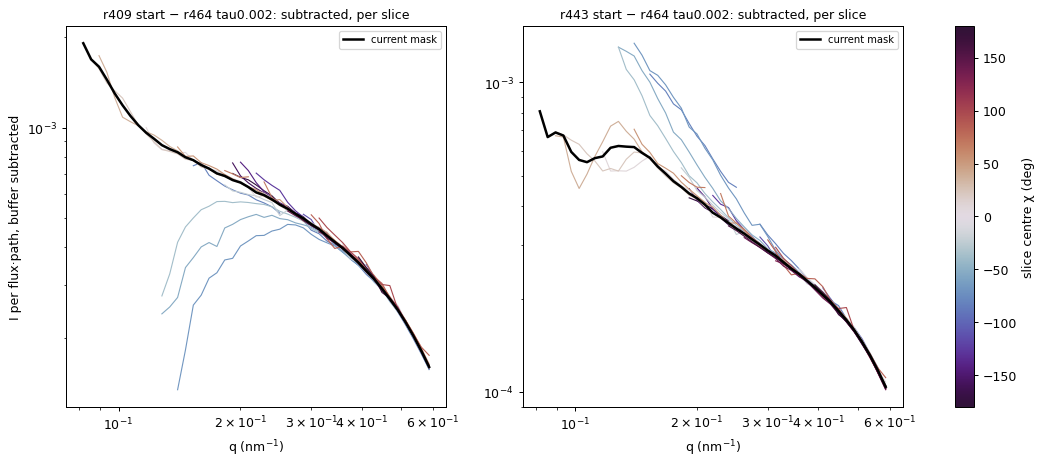

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5.5))
cmap = plt.get_cmap("twilight_shifted")
for ax, key in zip(axs, ["r409 start", "control r443 start"]):
    s, b = pairs[key]
    D, ref, _, npx = subtract(s, b, ~OPEN_MASK)
    for k in range(CC.size):
        y = np.where(HAS_DATA[:, k], D[:, k], np.nan)
        if np.isfinite(y).sum() >= 3:
            ax.loglog(QC, y, color=cmap((CC[k] + 180) / 360), lw=0.9)
    ax.loglog(QC, ref, "k", lw=2, label="current mask")
    ax.set_title(f"{s['name']} − {b['name']}: subtracted, per slice", fontsize=10)
    ax.set_xlabel("q (nm$^{-1}$)")
    ax.legend(fontsize=8)
axs[0].set_ylabel("I per flux·path, buffer subtracted")
fig.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(-180, 180), cmap=cmap), ax=axs, label="slice centre χ (deg)")
plt.show()

## 3. Which masked slices agree with the wedge after subtraction?

A cell **agrees** if its subtracted intensity is within the tolerance of the current mask's average at the same q. The
tolerance is the larger of 4× the block's own sector scatter (the rms difference between three sectors of the wedge at
q 0.2–0.5 nm⁻¹, about 0.75 %; the same criterion that defines q_min) and 3× the cell's Poisson error. Top row: standard
subtraction; bottom row: per-flux subtraction.

* **r409, either scaling:** below q ≈ 0.2 nm⁻¹ no masked cell agrees (the lobe), and above it the lobe core still fails.
  Outside the lobe core, masked cells above q ≈ 0.2 nm⁻¹ agree with the standard scaling.
* **Control, per flux:** most of the lobe agrees down to q ≈ 0.2 nm⁻¹ and about a third of it between 0.15 and 0.2 nm⁻¹;
  below 0.15 nm⁻¹ almost nothing does.
* **Inside the wedge** (dark red at the bottom) the slices disagree with each other below q ≈ 0.13 nm⁻¹ in every block:
  that is the q_min of section 5.

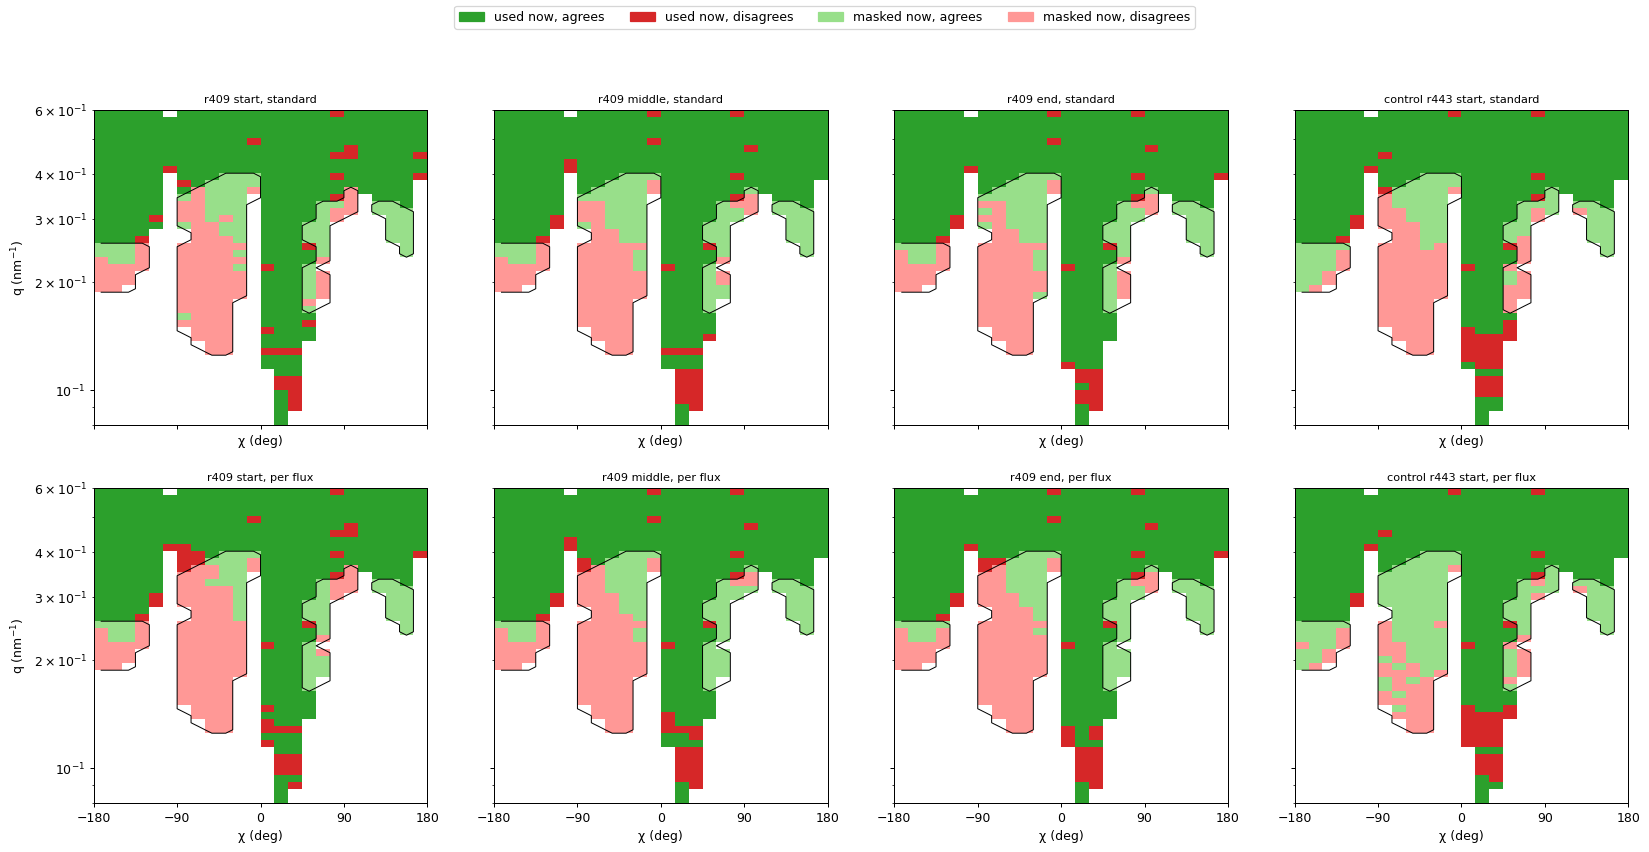

used now: px that agree  \
pair               subtraction q (nm⁻¹)                              
r409 start         standard    0.125–0.15                     1029   
                               0.15–0.2                       3128   
                               0.2–0.3                       18812   
                               0.3–0.42                      83902   
                   per flux    0.125–0.15                     1001   
                               0.15–0.2                       3157   
                               0.2–0.3                       18784   
                               0.3–0.42                      78672   
r409 middle        standard    0.125–0.15                     1063   
                               0.15–0.2                       3157   
                               0.2–0.3                       18784   
                               0.3–0.42                      84881   
                   per flux    0.125–0.15                     1010   
                               0.15–0.2                       3157   
                               0.2–0.3                       18784   
                               0.3–0.42                      83088   
r409 end           standard    0.125–0.15                     1353   
                               0.15–0.2                       3157   
                               0.2–0.3                       18784   
                               0.3–0.42                      84844   
                   per flux    0.125–0.15                     1204   
                               0.15–0.2                       3157   
                               0.2–0.3                       18784   
                               0.3–0.42                      81998   
control r443 start standard    0.125–0.15                      340   
                               0.15–0.2                       3128   
                               0.2–0.3                       18784   
                               0.3–0.42                      84030   
                   per flux    0.125–0.15                      340   
                               0.15–0.2                       3157   
                               0.2–0.3                       18940   
                               0.3–0.42                      84881   

                                           used now: px  \
pair               subtraction q (nm⁻¹)                   
r409 start         standard    0.125–0.15          1353   
                               0.15–0.2            3157   
                               0.2–0.3            19317   
                               0.3–0.42           85078   
                   per flux    0.125–0.15          1353   
                               0.15–0.2            3157   
                               0.2–0.3            19317   
                               0.3–0.42           85078   
r409 middle        standard    0.125–0.15          1353   
                               0.15–0.2            3157   
                               0.2–0.3            19317   
                               0.3–0.42           85078   
                   per flux    0.125–0.15          1353   
                               0.15–0.2            3157   
                               0.2–0.3            19317   
                               0.3–0.42           85078   
r409 end           standard    0.125–0.15          1353   
                               0.15–0.2            3157   
                               0.2–0.3            19317   
                               0.3–0.42           85078   
                   per flux    0.125–0.15          1353   
                               0.15–0.2            3157   
                               0.2–0.3            19317   
                               0.3–0.42           85078   
control r443 start standard    0.125–0.15          1353   
                               0.15–0.2            3157   
          

In [7]:
WEDGE_SECTORS = [(8, 25), (25, 35), (35, 50)]


def sector_scatter(s, b):
    "The wedge's own sector-to-sector scatter at q 0.2-0.5 and the lowest q where its sectors agree (as in q_min)."
    ys = []
    for lo, hi in WEDGE_SECTORS:
        sel = ~CURRENT & (CHI >= lo) & (CHI < hi)
        ys.append(average(s, sel) * scale(s) - (1 - s["phi"]) * average(b, sel) * scale(b))
    y = np.array(ys)
    rel = np.abs(y / np.nanmean(y, 0) - 1)
    floor = np.sqrt(np.nanmean(rel[:, (QC >= 0.2) & (QC <= 0.5)] ** 2))
    bad = (np.nanmax(rel, 0) > 4 * floor) & (QC < 0.25)
    pair = bad[:-1] & bad[1:]
    return floor, (QC[1:][pair].max() if pair.any() else QC[0])


def classify(s, b, mode):
    "0 used and agrees, 1 used and disagrees, 2 masked now and agrees, 3 masked now and disagrees (NaN: no pixels)."
    D, ref, err, _ = subtract(s, b, ~OPEN_MASK, mode)
    floor, _ = sector_scatter(s, b)
    agrees = np.abs(D / ref[:, None] - 1) <= np.maximum(4 * floor, 3 * err)
    cls = np.select([USED & agrees, USED & ~agrees, ~USED & agrees], [0.0, 1.0, 2.0], 3.0)
    return np.where(HAS_DATA, cls, np.nan), agrees


colors = ["#2ca02c", "#d62728", "#98df8a", "#ff9896"]
labels = ["used now, agrees", "used now, disagrees", "masked now, agrees", "masked now, disagrees"]
fig, axs = plt.subplots(2, 4, figsize=(22, 10), sharex=True, sharey=True)
agree = {}
rows = []
for col, (key, (s, b)) in enumerate(pairs.items()):
    for row, mode in enumerate(("standard", "per flux")):
        cls, agree[key, mode] = classify(s, b, mode)
        cell_map(axs[row, col], cls, f"{key}, {mode}", mpl.colors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], 4),
                 mpl.colors.ListedColormap(colors))
        for lo, hi in [(0.125, 0.15), (0.15, 0.2), (0.2, 0.3), (0.3, 0.42)]:
            r = ((QC >= lo) & (QC < hi))[:, None] & HAS_DATA
            rows.append({"pair": key, "subtraction": mode, "q (nm⁻¹)": f"{lo}–{hi}",
                         "used now: px that agree": int(ALL_NPX[r & USED & agree[key, mode]].sum()),
                         "used now: px": int(ALL_NPX[r & USED].sum()),
                         "masked now: px that agree": int(ALL_NPX[r & ~USED & agree[key, mode]].sum()),
                         "masked now: px": int(ALL_NPX[r & ~USED].sum())})
for ax in axs[:, 0]:
    ax.set_ylabel("q (nm$^{-1}$)")
fig.legend(handles=[mpl.patches.Patch(color=c, label=l) for c, l in zip(colors, labels)], loc="upper center", ncol=4)
plt.show()
pixels = pd.DataFrame(rows).set_index(["pair", "subtraction", "q (nm⁻¹)"])
pixels

## 4. A candidate mask for r409

The candidate keeps everything the current mask uses and adds the masked cells that agree in **all three** r409 blocks
with the standard subtraction. Below, the I(q) it gives is compared with the current one. The candidate only exists
in this notebook; the mask file in `usr/masks` is unchanged.

candidate opens 30503 px, at q 0.164-0.401 nm^-1


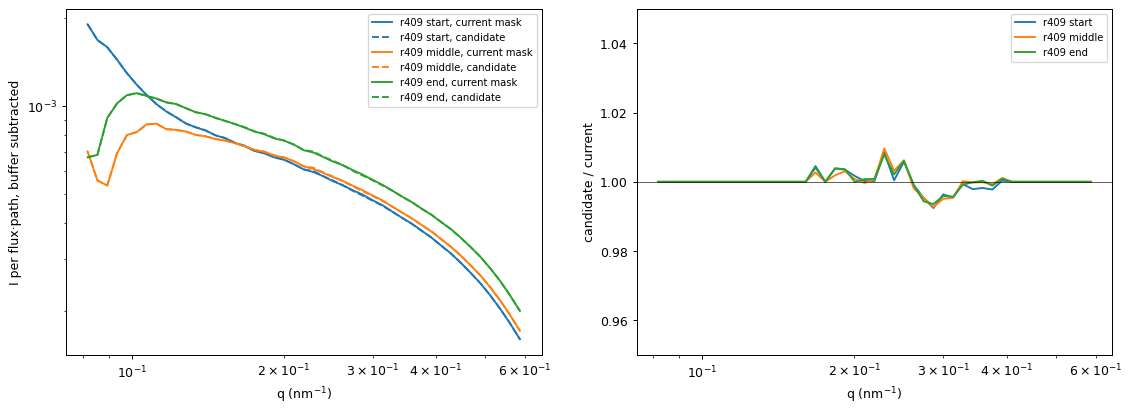

,current mask,candidate,gain
q (nm⁻¹),,,
0.125–0.150,1383,1383,1.000
0.150–0.200,3779,4352,1.152
0.200–0.300,17592,29775,1.693
0.300–0.420,86999,104746,1.204


In [8]:
r409_keys = ["r409 start", "r409 middle", "r409 end"]
open_cells = ~USED & HAS_DATA & np.all([agree[k, "standard"] for k in r409_keys], axis=0)
in_range = (QBIN >= 0) & (QBIN < QC.size)
opened_px = ~OPEN_MASK & CURRENT & in_range
opened_px[in_range] &= open_cells[QBIN[in_range], CBIN[in_range]]
CANDIDATE = CURRENT & ~opened_px  # True = excluded
print(f"candidate opens {opened_px.sum()} px, at q {Q[opened_px].min():.3f}-{Q[opened_px].max():.3f} nm^-1")

fig, axs = plt.subplots(1, 2, figsize=(15, 5))
for key in r409_keys:
    s, b = pairs[key]
    w = 1 - s["phi"]
    d_cur = average(s, ~CURRENT) * scale(s) - w * average(b, ~CURRENT) * scale(b)
    d_new = average(s, ~CANDIDATE) * scale(s) - w * average(b, ~CANDIDATE) * scale(b)
    axs[0].loglog(QC, d_cur, label=f"{key}, current mask")
    axs[0].loglog(QC, d_new, "--", color=axs[0].lines[-1].get_color(), label=f"{key}, candidate")
    axs[1].semilogx(QC, d_new / d_cur, label=key)
axs[0].set_ylabel("I per flux·path, buffer subtracted")
axs[1].set_ylabel("candidate / current")
axs[1].axhline(1, color="k", lw=0.5)
axs[1].set_ylim(0.95, 1.05)
for ax in axs:
    ax.set_xlabel("q (nm$^{-1}$)")
    ax.legend(fontsize=8)
plt.show()

rows = []
for lo, hi in [(0.125, 0.15), (0.15, 0.20), (0.20, 0.30), (0.30, 0.42)]:
    ring = (Q >= lo) & (Q < hi)
    rows.append({"q (nm⁻¹)": f"{lo:.3f}–{hi:.3f}", "current mask": int((ring & ~CURRENT).sum()),
                 "candidate": int((ring & ~CANDIDATE).sum())})
tab = pd.DataFrame(rows).set_index("q (nm⁻¹)")
tab["gain"] = tab["candidate"] / tab["current mask"]
tab

### The candidate mask on the detector

Left: what each pixel near the beam is under the candidate. Light blue pixels are used by the current mask already; green
pixels are the near-beam pixels the candidate opens; red pixels are near-beam pixels it keeps masked (the stray-light
lobe and the cells that did not agree); dark grey is the base mask. Thin grey rays mark the 15° slice edges, green
contours q in nm⁻¹. Middle: r409 start (photons per pixel per frame, 50 trains) with the candidate applied; masked pixels
are blank. Right: the same in (q, χ) cells.

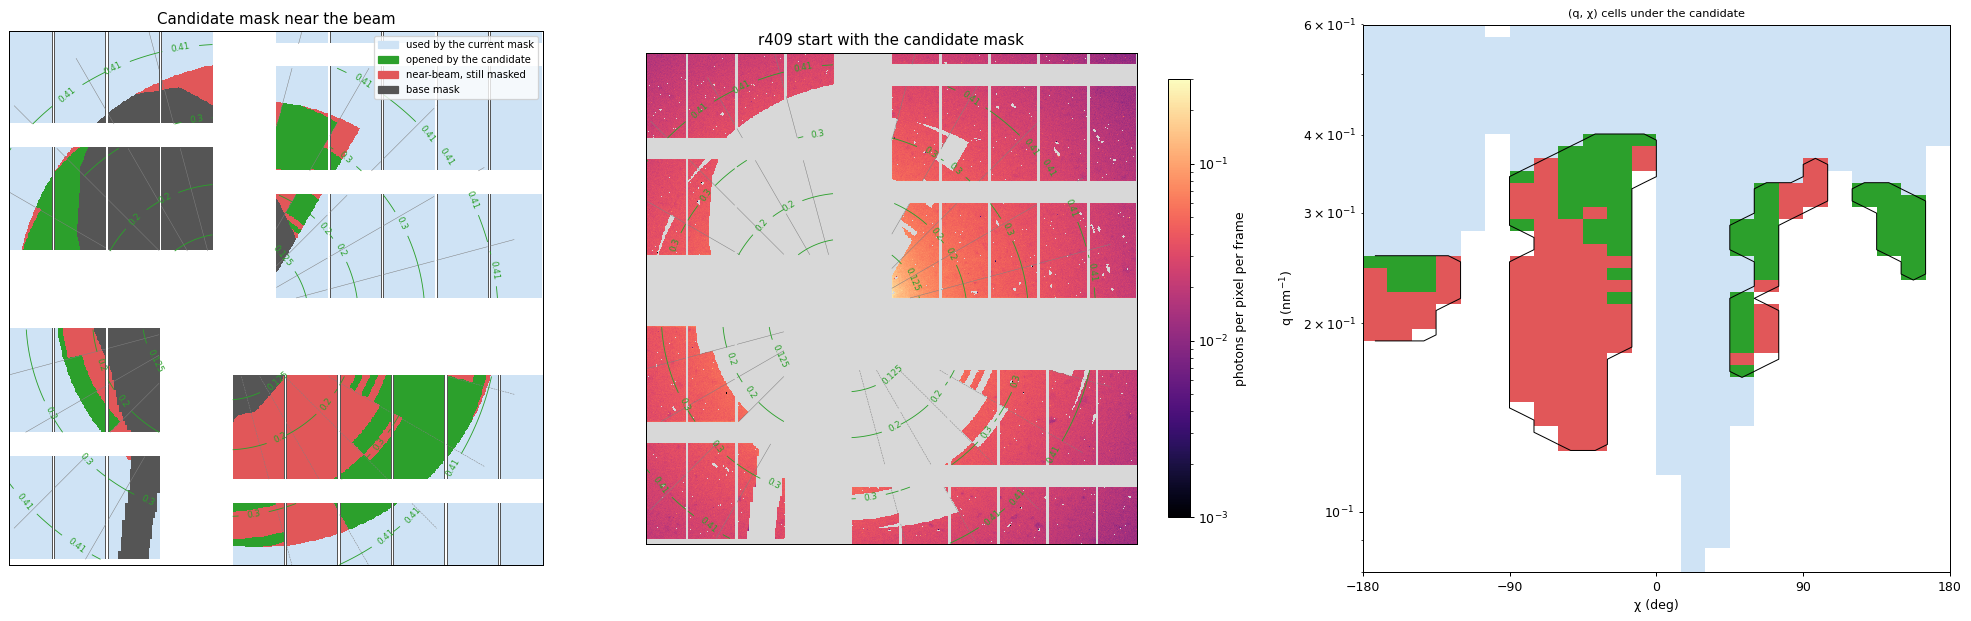

In [9]:
CHI_A, _ = GEOM.position_modules(CHI)
category = np.select([~CURRENT, opened_px, NEAR_BEAM], [0.0, 1.0, 2.0], 3.0)
s0 = pairs["r409 start"][0]
mean0 = np.where((s0["valid"] > 0) & ~CANDIDATE, s0["counts"] / np.maximum(s0["valid"], 1), np.nan)
half = 330
w = (slice(BEAM[0] - half, BEAM[0] + half), slice(BEAM[1] - half, BEAM[1] + half))


def slice_edges(ax):
    "15-degree slice edges as rays; chi is cut at +-180, so each edge is drawn from a field whose cut is far from it."
    near = QA[w] < 0.45
    for field, levels, keep in [(CHI_A[w], [e for e in CE[1:-1] if abs(e) < 90], np.abs(CHI_A[w]) < 150),
                                (np.mod(CHI_A[w], 360), [e % 360 for e in CE[1:-1] if abs(e) >= 90],
                                 np.abs(CHI_A[w]) > 30)]:
        ax.contour(np.where(near & keep, field, np.nan), levels=sorted(levels), colors="0.5", linewidths=0.4)


colors = ["#cfe3f5", "#2ca02c", "#e15759", "#555555"]
labels = ["used by the current mask", "opened by the candidate", "near-beam, still masked", "base mask"]
fig, axs = plt.subplots(1, 3, figsize=(22, 7), gridspec_kw={"width_ratios": [1, 1.15, 1.1]})
img, _ = GEOM.position_modules(category)
cmap = mpl.colors.ListedColormap(colors)
cmap.set_bad("white")
axs[0].imshow(img[w], cmap=cmap, norm=mpl.colors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], 4), origin="lower",
              interpolation="nearest")
axs[0].legend(handles=[mpl.patches.Patch(color=c, label=l) for c, l in zip(colors, labels)], fontsize=8,
              loc="upper right")
axs[0].set_title("Candidate mask near the beam")

img, _ = GEOM.position_modules(mean0)
cm = plt.get_cmap("magma").copy()
cm.set_bad("0.85")
im = axs[1].imshow(img[w], norm=LogNorm(1e-3, 3e-1), cmap=cm, origin="lower", interpolation="nearest")
fig.colorbar(im, ax=axs[1], shrink=0.8, label="photons per pixel per frame")
axs[1].set_title(f"{s0['name']} with the candidate mask")
for ax in axs[:2]:
    slice_edges(ax)
    cs = ax.contour(QA[w], levels=[0.125, 0.2, 0.3, 0.41], colors="tab:green", linewidths=0.7)
    ax.clabel(cs, fmt="%.3g", fontsize=7)
    ax.set_xticks([])
    ax.set_yticks([])

cell_class = np.select([USED, open_cells], [0.0, 1.0], 2.0)
cell_map(axs[2], cell_class, "(q, χ) cells under the candidate", mpl.colors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5], 3),
         mpl.colors.ListedColormap(colors[:3]))
axs[2].set_ylabel("q (nm$^{-1}$)")
plt.tight_layout()
plt.show()

## 5. How low does the wedge itself go for r409?

The lowest q where the three wedge sectors still agree (the definition behind the q_min rule of `damnit_saxs.ipynb`),
compared with the rule q_min = 0.156 nm⁻¹ per mm of horizontal semi-axis a_x. The rule was measured on the 12 May droplet
r443–452; r409 starts very flat (vertical semi-axis 0.46 mm against 1.23 mm horizontal), so a_x overstates its size.
Below q_min the current-mask I(q) is not trustworthy: in the plot of section 4, r409 middle and end turn over below
q ≈ 0.105 nm⁻¹ while the start keeps rising.

In [10]:
rows = []
for key, (s, b) in pairs.items():
    floor, qmin = sector_scatter(s, b)
    rows.append({"pair": key, "a_x (mm)": s["a_x"], "sector scatter": floor, "q_min found": qmin,
                 "rule 0.156·a_x": 0.156 * s["a_x"]})
pd.DataFrame(rows).set_index("pair")

,a_x (mm),sector scatter,q_min found,rule 0.156·a_x
pair,,,,
r409 start,1.227,0.007,0.128,0.191
r409 middle,0.873,0.008,0.134,0.136
r409 end,0.819,0.007,0.128,0.128
control r443 start,0.960,0.008,0.140,0.150


## 6. The 11 May stray light and the r318 beam-only pattern

The only droplet-free data near 11 May is the r318 mesh scan (11 May 13:22, attenuator 0.1, 350 pulses), in trains where the
beam passes below the droplet. Its slice pattern has the lobe in the same directions as r409's, but much stronger relative
to its (weak, air-only) average. The table gives the lobe's excess over the current-mask average per unit of logged flux.
r318 sits ~3× above r409 at every q, while the 12 May buffer's ratio to r409 varies from 3× to 16×. r318 is therefore
the closer match to the 11 May stray light, but its absolute scale (attenuator 0.1, a different pulse pattern, no droplet
to cast a shadow) does not transfer.

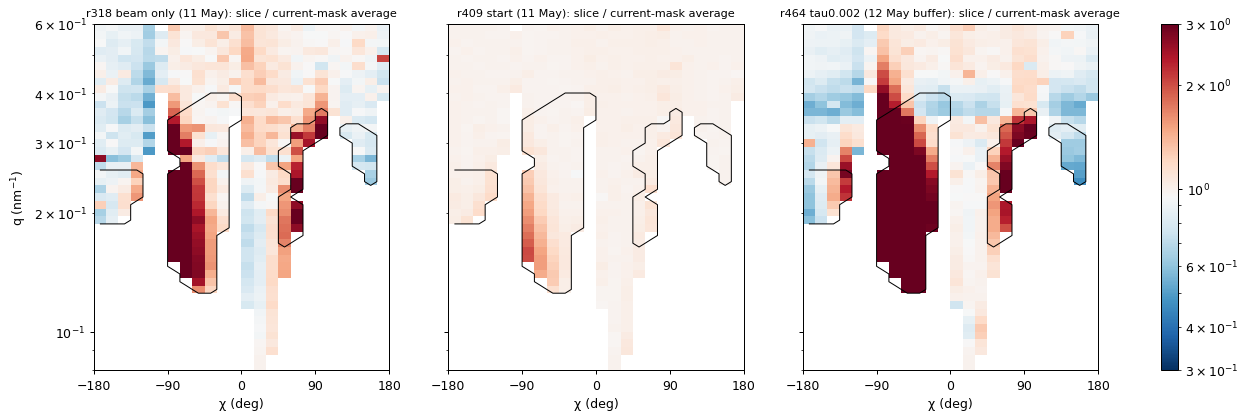

,r409 start (×1e6 per flux),r464 buffer (×1e6 per flux),r318 beam only (×1e6 per flux),r464 / r409,r318 / r409
q (nm⁻¹),,,,,
0.128,22.100,351.119,84.607,15.888,3.828
0.160,91.481,312.128,252.233,3.412,2.757
0.200,27.464,115.419,87.526,4.202,3.187
0.251,7.019,39.823,26.843,5.674,3.824


In [11]:
MESH_RUN, MESH_PULSES = 318, 350
rd318 = cache.saxs_run(MESH_RUN, db, n_pulses=MESH_PULSES)
raw318 = ed.open_run(10400, MESH_RUN, data="raw")
pos = xr.Dataset({"x": raw318["MID_EXP_SAM/HEXAPOD/SSHEX", "X.actualPosition.value"].xarray(),
                  "z": raw318["MID_EXP_SAM/HEXAPOD/SSHEX", "Z.actualPosition.value"].xarray()})
complete = (rd318.n_pulses_with_frames == MESH_PULSES) & np.isfinite(rd318.flux)
water = (rd318.intensity.sel(q=slice(0.85, 0.95)).mean("q") / rd318.flux).where(complete)
mesh = xr.merge([pos, water.rename("water")], join="inner").dropna("trainId")
z_low = mesh.z < float(mesh.z.min()) + 0.05
beam_only = z_low & ~(mesh.water > 2 * float(mesh.water.where(z_low).median()))
tids = mesh.trainId.values[beam_only.values]
tids = tids[np.linspace(0, tids.size - 1, min(60, tids.size)).round().astype(int)]  # as in lowq_report.ipynb
bo = block_from_sums(MESH_RUN, cache.detector_sums(MESH_RUN, tids, label="beamonly"), rd318, "beamonly")

s, b = pairs["r409 start"]
fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, blk, title in [(axs[0], bo, "r318 beam only (11 May)"), (axs[1], s, f"{s['name']} (11 May)"),
                       (axs[2], b, f"{b['name']} (12 May buffer)")]:
    X, _, _ = cells(blk, ~OPEN_MASK)
    im = cell_map(ax, X / average(blk, ~CURRENT)[:, None], f"{title}: slice / current-mask average", LogNorm(0.3, 3))
fig.colorbar(im, ax=axs)
axs[0].set_ylabel("q (nm$^{-1}$)")
plt.show()

lobe = (CC > -90) & (CC < -20)
rows = []
for qq in (0.13, 0.16, 0.20, 0.25):
    i = int(np.argmin(abs(QC - qq)))
    sel = lobe & HAS_DATA[i]
    ex = {}
    for name, blk in [("r409 start", s), ("r464 buffer", b), ("r318 beam only", bo)]:
        X, _, _ = cells(blk, ~OPEN_MASK)
        ex[name] = float(np.nanmean(X[i, sel] - average(blk, ~CURRENT)[i]) / blk["flux"] * 1e6)
    rows.append({"q (nm⁻¹)": round(QC[i], 3), **{f"{k} (×1e6 per flux)": v for k, v in ex.items()},
                 "r464 / r409": ex["r464 buffer"] / ex["r409 start"], "r318 / r409": ex["r318 beam only"] / ex["r409 start"]})
pd.DataFrame(rows).set_index("q (nm⁻¹)")

## 7. What this means

* **Mask.** Slice-wise subtraction cannot open the mask below q ≈ 0.2 nm⁻¹ for r409: the only masked slices there are the
  stray-light lobe, and the available buffer carries a different (12 May) lobe. Above ≈ 0.22 nm⁻¹ the candidate of section
  4 adds 1.3–1.8× more pixels with an unchanged I(q). The lowest q remains the wedge's, which for r409 is consistent down to
  ≈ 0.13 nm⁻¹ in all three blocks.
* **For 12 May samples** (r443–462 at attenuator 1.0; r467 onward needs the 0.506 flux correction), the lobe slices could
  be used down to ≈ 0.2 nm⁻¹ with the per-flux subtraction. Worth testing on the plateau blocks next.
* **For 11 May samples** (r394–400, r409–419, r423–433), a stray-light reference from the same period is missing; r318 has
  the right pattern but an unknown relative scale. Without one, the 11 May lobe cannot be subtracted, only masked.
* **The q_min rule** overstates r409's limit at its start (0.19 vs 0.13 nm⁻¹ found). It was derived on one droplet; a
  per-droplet sector check, as in section 5, is safer than the rule when the droplet's shape differs.